# Taller: Z-Buffer y Depth Testing
## Notebook 2 — Visualización del Depth Buffer y Problemas de Precisión

Este notebook cubre:
- **Sección 4:** Visualización del depth buffer normalizado (escala de grises)
- **Sección 5:** Experimentación con near/far planes, Z-fighting y pérdida de precisión

---
## Setup — Re-importar utilidades del Notebook 1

> Este notebook es autónomo: re-define todas las funciones necesarias.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image

WIDTH  = 512
HEIGHT = 512

# Proyección perspectiva 
def project_point(point3d, focal_length=500, cx=WIDTH//2, cy=HEIGHT//2):
    x, y, z = point3d
    if z <= 0:
        z = 0.001
    px = int(focal_length * x / z + cx)
    py = int(focal_length * y / z + cy)
    return px, py

def project_triangle(triangle3d, focal_length=500):
    return [project_point(v, focal_length) for v in triangle3d]

#  Función de arista 
def edge_function(a, b, p):
    return (p[0] - a[0]) * (b[1] - a[1]) - (p[1] - a[1]) * (b[0] - a[0])

#  Rasterización con Z-buffer 
def rasterize_triangle_zbuffer(color_buffer, depth_buffer, triangle3d, color,
                               focal_length=500):
    v0, v1, v2 = triangle3d
    z0, z1, z2 = v0[2], v1[2], v2[2]
    p0 = project_point(v0, focal_length)
    p1 = project_point(v1, focal_length)
    p2 = project_point(v2, focal_length)

    min_x = max(0, min(p0[0], p1[0], p2[0]))
    max_x = min(WIDTH  - 1, max(p0[0], p1[0], p2[0]))
    min_y = max(0, min(p0[1], p1[1], p2[1]))
    max_y = min(HEIGHT - 1, max(p0[1], p1[1], p2[1]))

    area = edge_function(p0, p1, p2)
    if area == 0:
        return

    for y in range(min_y, max_y + 1):
        for x in range(min_x, max_x + 1):
            p = (x, y)
            w0 = edge_function(p1, p2, p)
            w1 = edge_function(p2, p0, p)
            w2 = edge_function(p0, p1, p)
            if (w0 >= 0 and w1 >= 0 and w2 >= 0) or (w0 <= 0 and w1 <= 0 and w2 <= 0):
                lam0 = w0 / area
                lam1 = w1 / area
                lam2 = w2 / area
                z_interp = lam0 * z0 + lam1 * z1 + lam2 * z2
                if z_interp < depth_buffer[y, x]:
                    depth_buffer[y, x] = z_interp
                    color_buffer[y, x] = color


def render_zbuffer(triangles, focal_length=500):
    color_buffer = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    depth_buffer = np.full((HEIGHT, WIDTH), np.inf)
    for verts3d, color, *_ in triangles:
        rasterize_triangle_zbuffer(color_buffer, depth_buffer, verts3d, color, focal_length)
    return color_buffer, depth_buffer


---
## Sección 4 — Visualización del Depth Buffer

### 4.1 Escena de referencia con gradiente de profundidad

In [2]:
# Escena con varios planos de profundidad 
depth_scene = [
    # (vértices 3D,                                                 color,           nombre)
    ([(-0.9, -0.9, 1.5), ( 0.9, -0.9, 1.5), ( 0.0,  0.0, 1.5)],  (200, 100,  60), "Triang z=1.5"),
    ([(-0.7,  0.0, 2.5), ( 0.3, -0.8, 2.5), ( 0.8,  0.8, 2.5)],  ( 80, 160, 220), "Triang z=2.5"),
    ([(-0.5, -0.5, 3.5), ( 0.9,  0.2, 4.0), (-0.1,  0.9, 3.8)],  ( 80, 200,  90), "Triang z≈3.5-4"),
    ([(-0.8,  0.5, 5.0), ( 0.8,  0.5, 5.0), ( 0.0, -0.5, 5.5)],  (200,  60, 200), "Triang z≈5-5.5"),
    ([(-1.0, -1.0, 7.0), ( 1.0, -1.0, 7.0), ( 0.0,  1.0, 7.0)],  (230, 200,  50), "Triang z=7 (fondo)"),
]

color_img, depth_buf = render_zbuffer(depth_scene)

finite_vals = depth_buf[np.isfinite(depth_buf)]
print(f"Rango de profundidades: [{finite_vals.min():.3f}, {finite_vals.max():.3f}]")
print(f"Píxeles con geometría: {len(finite_vals):,}")

Rango de profundidades: [1.500, 5.062]
Píxeles con geometría: 96,722


### 4.2 Normalización del depth buffer a [0, 1] → escala de grises

Para visualizar el Z-buffer se normaliza al rango $[0, 1]$:

$$depth_{norm}(x,y) = \frac{z(x,y) - z_{min}}{z_{max} - z_{min}}$$

Píxeles **oscuros** = más cercanos; píxeles **claros** = más lejanos.

In [3]:
def normalize_depth_buffer(depth_buffer):
    """
    Normaliza el depth buffer al rango [0, 1].
    Los píxeles sin geometría (infinito) se muestran en blanco (1.0).
    """
    db_vis = depth_buffer.copy()
    
    valid_mask = np.isfinite(db_vis)
    if not valid_mask.any():
        return np.ones_like(db_vis)
    
    z_min = db_vis[valid_mask].min()
    z_max = db_vis[valid_mask].max()
    
    # Normalizar píxeles válidos
    db_vis[valid_mask] = (db_vis[valid_mask] - z_min) / (z_max - z_min + 1e-10)
    
    # Fondo (sin geometría) → blanco
    db_vis[~valid_mask] = 1.0
    
    return db_vis


def depth_to_grayscale_image(depth_buffer):
    """Convierte depth buffer normalizado a imagen PIL en escala de grises (uint8)."""
    norm = normalize_depth_buffer(depth_buffer)
    gray_uint8 = (norm * 255).astype(np.uint8)
    return Image.fromarray(gray_uint8, mode='L')


depth_normalized = normalize_depth_buffer(depth_buf)
depth_pil = depth_to_grayscale_image(depth_buf)
depth_pil.save('depth_buffer_grayscale.png')
print("Depth buffer normalizado.")
print(f"Rango tras normalización: [{depth_normalized[np.isfinite(depth_buf)].min():.4f}, "
      f"{depth_normalized[np.isfinite(depth_buf)].max():.4f}]")

Depth buffer normalizado.
Rango tras normalización: [0.0000, 1.0000]


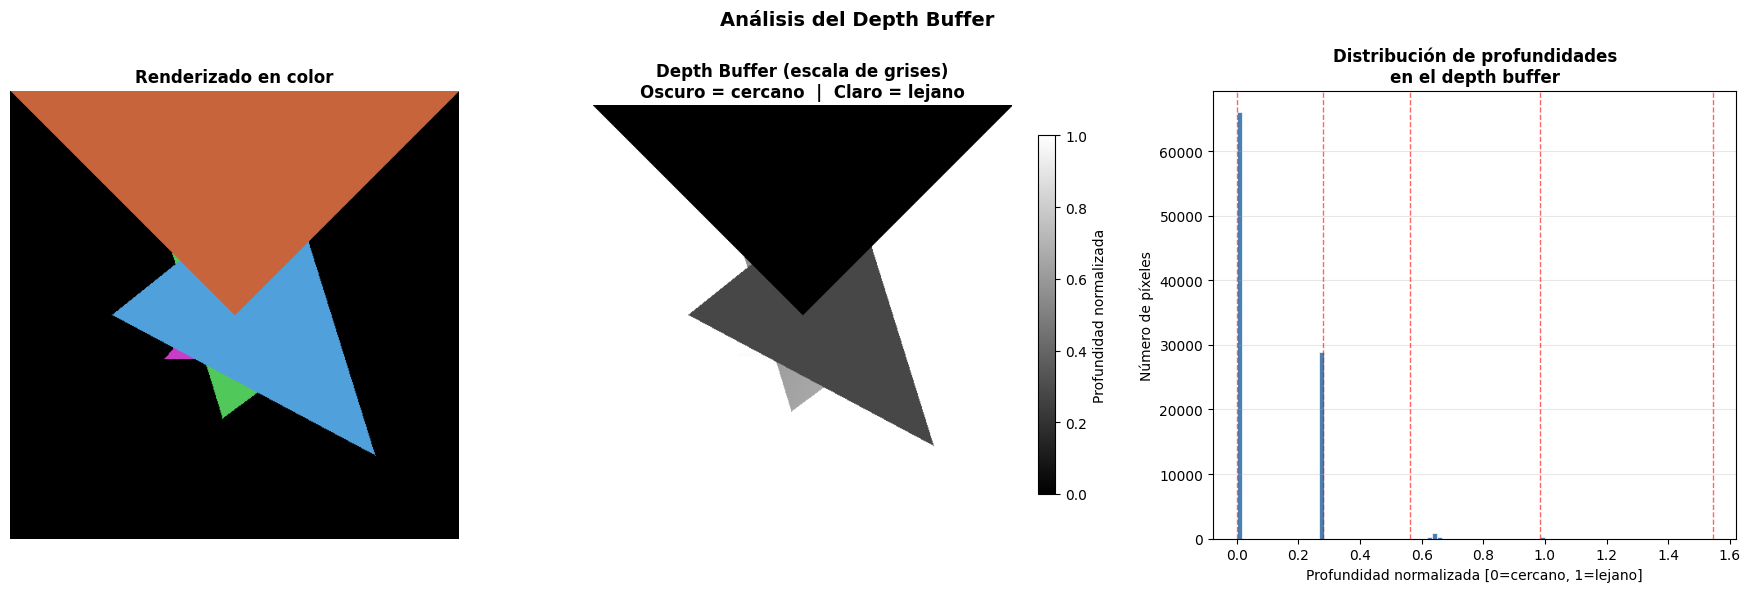

In [4]:
# ─── Visualización completa: color + depth buffer + histograma ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Imagen en color
axes[0].imshow(color_img)
axes[0].set_title("Renderizado en color", fontsize=12, fontweight='bold')
axes[0].axis('off')

# 2. Depth buffer en escala de grises
im = axes[1].imshow(depth_normalized, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Depth Buffer (escala de grises)\nOscuro = cercano  |  Claro = lejano",
                  fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], shrink=0.8, label='Profundidad normalizada')

# 3. Histograma de distribución de profundidades
finite_norm = depth_normalized[np.isfinite(depth_buf)]
axes[2].hist(finite_norm, bins=60, color='steelblue', edgecolor='white',
             linewidth=0.5)
axes[2].set_xlabel('Profundidad normalizada [0=cercano, 1=lejano]', fontsize=10)
axes[2].set_ylabel('Número de píxeles', fontsize=10)
axes[2].set_title('Distribución de profundidades\nen el depth buffer', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

# Líneas en z de cada triángulo original
finite_min = finite_vals.min()
finite_max = finite_vals.max()
for _, _, name in depth_scene:
    z_val = float(name.replace('≈', '=').split('z=')[1].split()[0].split('-')[0])
    norm_z = (z_val - finite_min) / (finite_max - finite_min)
    axes[2].axvline(norm_z, color='red', linestyle='--', alpha=0.6, linewidth=1)

fig.suptitle("Análisis del Depth Buffer", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_buffer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Depth buffer con mapa de colores (jet/viridis)

También se puede visualizar con colormaps para analizar mejor los gradientes.

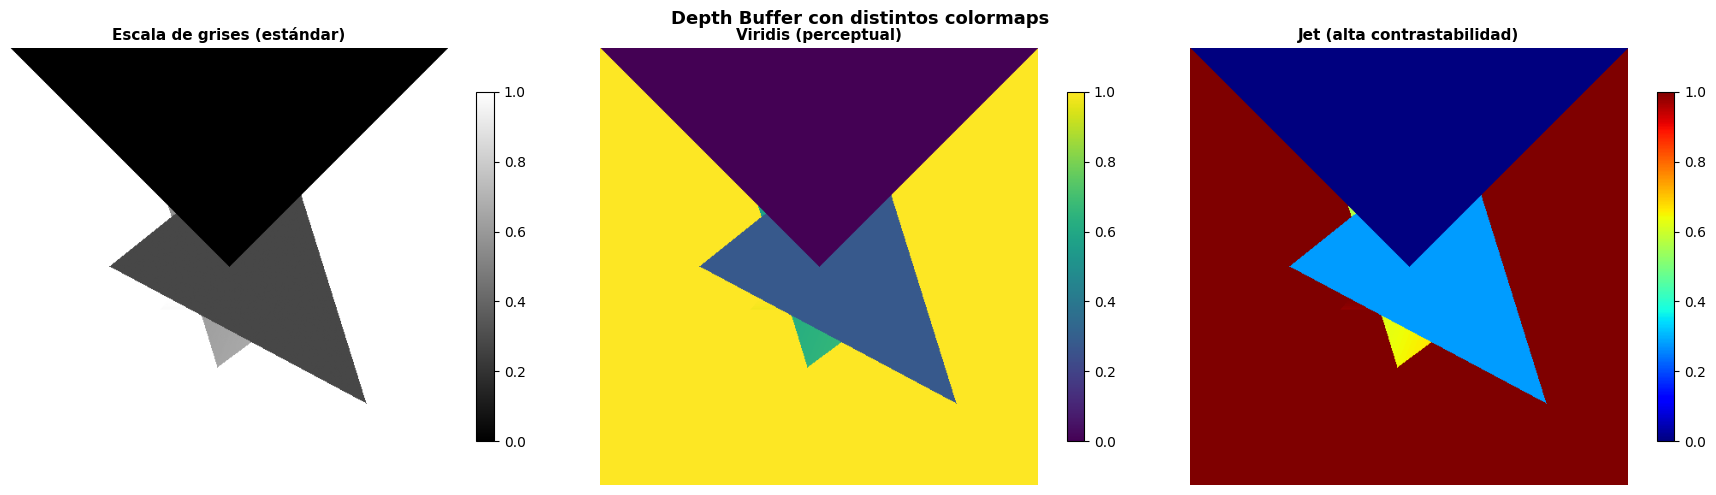

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['gray', 'viridis', 'jet']
cmap_names = ['Escala de grises (estándar)', 'Viridis (perceptual)', 'Jet (alta contrastabilidad)']

for ax, cmap, title in zip(axes, cmaps, cmap_names):
    im = ax.imshow(depth_normalized, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("Depth Buffer con distintos colormaps", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_buffer_colormaps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 5 — Experimentación con Precisión del Z-Buffer

### 5.1 Efecto del rango near/far en la distribución de profundidades

En hardware real el Z-buffer almacena un valor normalizado:

$$z_{ndc} = \frac{z_{far} \cdot (z - z_{near})}{z \cdot (z_{far} - z_{near})}$$

La precisión se concentra cerca de `near_plane`.
Un rango $[z_{near}, z_{far}]$ muy amplio deja muy poca precisión en zonas lejanas.

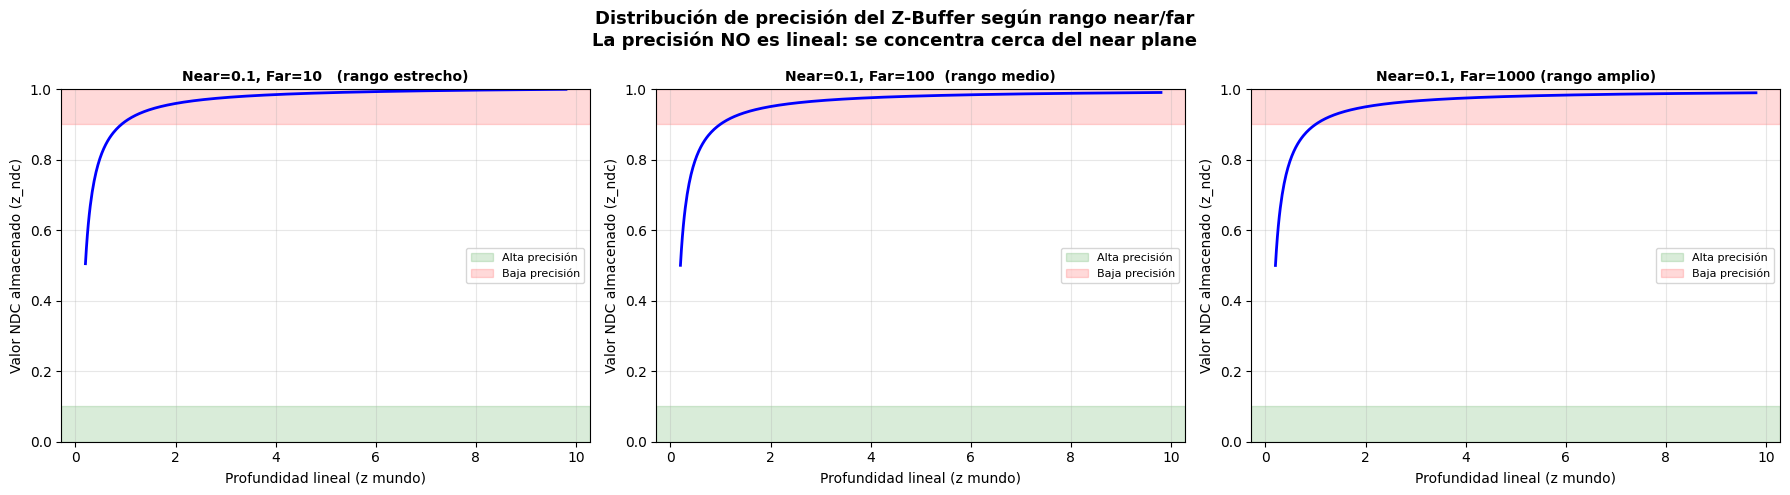

In [6]:
def linearize_depth_ndc(z_world, z_near, z_far):
    """
    Convierte profundidad en espacio mundo al valor NDC que almacenaría
    un Z-buffer de hardware (valor en [0, 1]).
    """
    return (z_far * (z_world - z_near)) / (z_world * (z_far - z_near))


def ndc_to_linear(z_ndc, z_near, z_far):
    """Reconstruye profundidad lineal desde valor NDC."""
    return (z_near * z_far) / (z_far - z_ndc * (z_far - z_near))


# ─── Comparar distribución con distintos rangos near/far ─────────────────────
configurations = [
    (0.1,  10.0,  "Near=0.1, Far=10   (rango estrecho)"),
    (0.1,  100.0, "Near=0.1, Far=100  (rango medio)"),
    (0.1, 1000.0, "Near=0.1, Far=1000 (rango amplio)"),
]

z_values = np.linspace(0.2, 9.8, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (near, far, label) in zip(axes, configurations):
    ndc_vals = linearize_depth_ndc(z_values, near, far)
    valid_mask = np.isfinite(ndc_vals) & (ndc_vals >= 0) & (ndc_vals <= 1)
    
    ax.plot(z_values[valid_mask], ndc_vals[valid_mask], 'b-', linewidth=2)
    ax.set_xlabel('Profundidad lineal (z mundo)', fontsize=10)
    ax.set_ylabel('Valor NDC almacenado (z_ndc)', fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)
    
    # Sombrear zona de alta precisión (ndc < 0.1)
    ax.axhspan(0, 0.1, alpha=0.15, color='green', label='Alta precisión')
    ax.axhspan(0.9, 1.0, alpha=0.15, color='red', label='Baja precisión')
    ax.legend(fontsize=8)

fig.suptitle("Distribución de precisión del Z-Buffer según rango near/far\n"
             "La precisión NO es lineal: se concentra cerca del near plane",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('zbuffer_precision_nearfar.png', dpi=150, bbox_inches='tight')
plt.show()

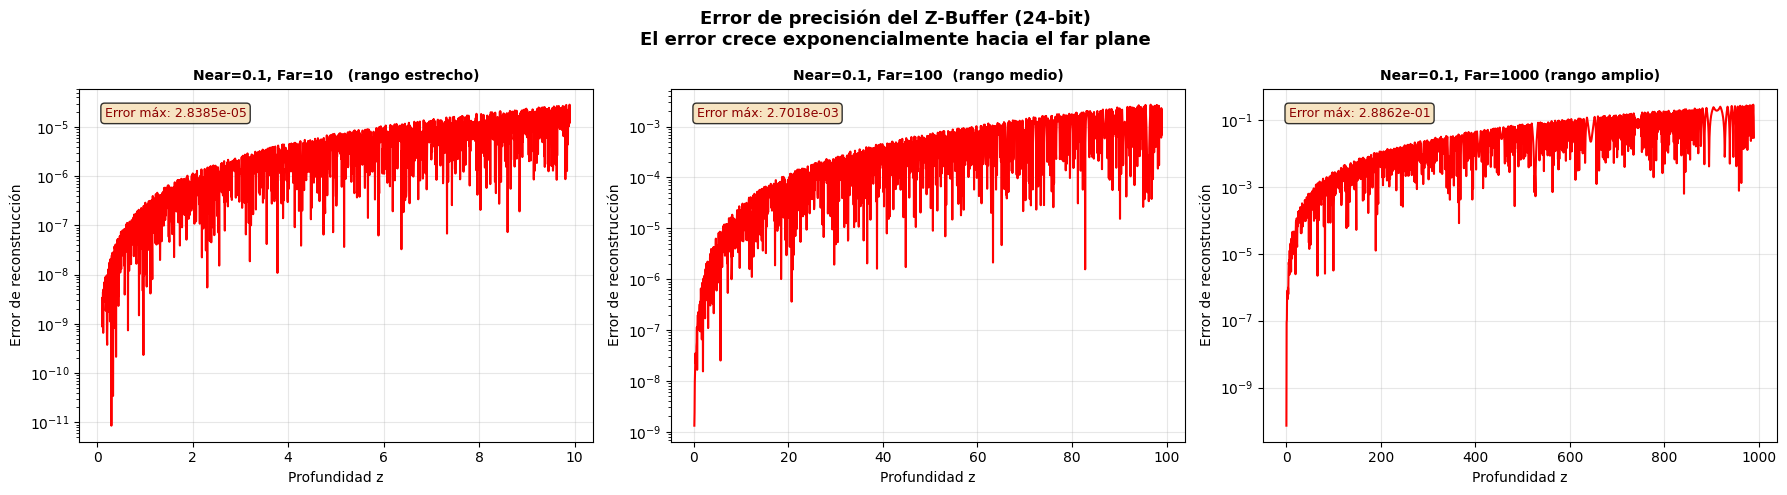

In [7]:
# ─── Cuantizar el efecto de la precisión con 24 bits (como hardware) ─────────
BIT_DEPTH = 24
NUM_LEVELS = 2 ** BIT_DEPTH  # 16,777,216 niveles

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (near, far, label) in zip(axes, configurations):
    z_range = np.linspace(near + 0.01, far * 0.99, 2000)
    ndc_continuous = linearize_depth_ndc(z_range, near, far)
    valid = np.isfinite(ndc_continuous) & (ndc_continuous >= 0) & (ndc_continuous <= 1)

    # Cuantizar al número de bits disponibles
    ndc_quantized = np.round(ndc_continuous[valid] * NUM_LEVELS) / NUM_LEVELS
    z_reconstructed = ndc_to_linear(ndc_quantized, near, far)
    error_m = np.abs(z_range[valid] - z_reconstructed)

    ax.semilogy(z_range[valid], error_m, 'r-', linewidth=1.5)
    ax.set_xlabel('Profundidad z', fontsize=10)
    ax.set_ylabel('Error de reconstrucción', fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

    max_err = error_m.max()
    ax.text(0.05, 0.92, f'Error máx: {max_err:.4e}',
            transform=ax.transAxes, fontsize=9, color='darkred',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig.suptitle(f"Error de precisión del Z-Buffer ({BIT_DEPTH}-bit)\n"
             "El error crece exponencialmente hacia el far plane",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('zbuffer_precision_error.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Z-Fighting — Simulación con objetos muy cercanos

El **Z-fighting** ocurre cuando dos superficies **se cruzan en profundidad**: en algunos píxeles A está delante de B, y en otros B está delante de A.
Cuando la diferencia de profundidad es tan pequeña que el Z-buffer no puede distinguirlos, el resultado es un **patrón caótico e irregular**.


Para demostrarlo correctamente usamos dos triángulos **inclinados en sentido opuesto** que se cruzan:Con `z_delta` grande → división limpia. Con `z_delta` mínimo → Z-fighting visible.

- Triángulo **Rojo**: izquierda cercana, derecha lejana
- Triángulo **Azul**: izquierda lejana, derecha cercana (opuesto)

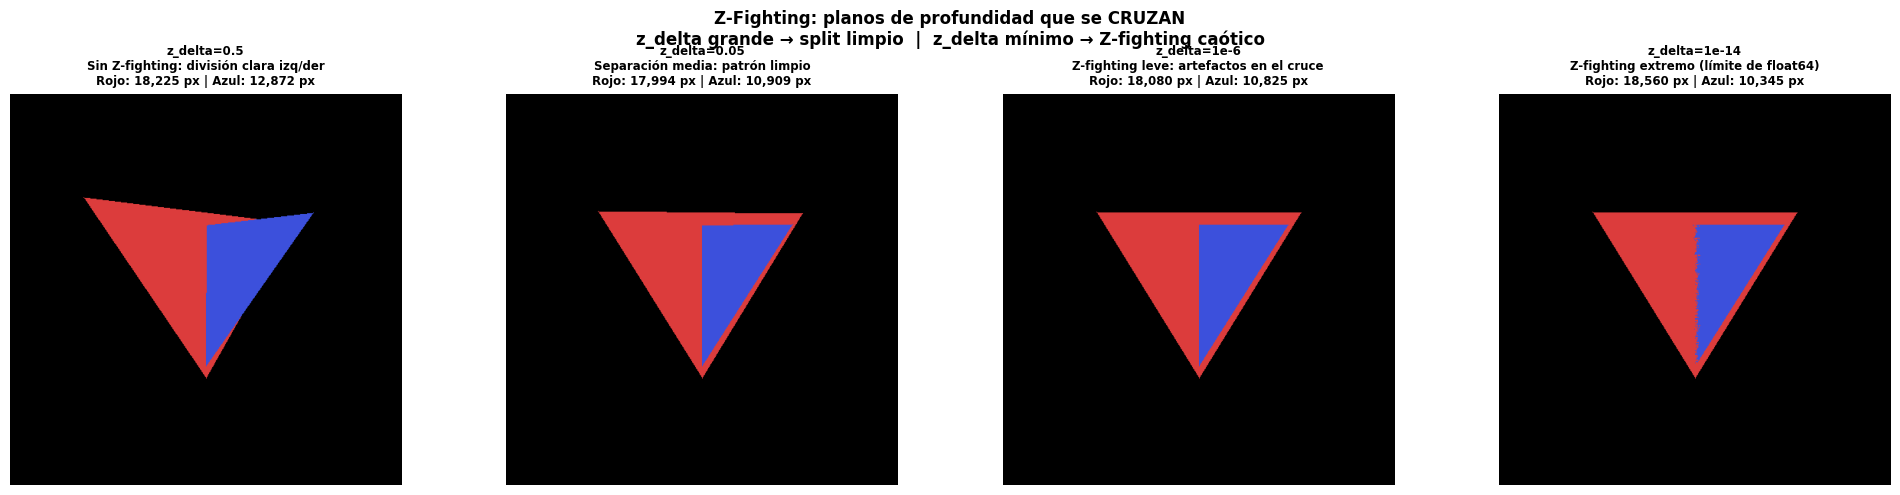

In [8]:
def render_zfighting_scene(z_delta, focal_length=500):
    """
    Renderiza dos triángulos inclinados cuyos planos de profundidad se CRUZAN.
    - Rojo: izquierda más cercana (base_z - z_delta), derecha más lejana (base_z + z_delta)
    - Azul: izquierda más lejana (base_z + z_delta), derecha más cercana (base_z - z_delta)

    Con z_delta grande → split limpio izq/der.
    Con z_delta muy pequeño → Z-fighting: el rasterizador no distingue qué está delante.
    """
    color_buffer = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    depth_buffer = np.full((HEIGHT, WIDTH), np.inf)

    base_z = 3.0

    # Rojo: izq. cercana (base_z - z_delta), der. lejana (base_z + z_delta)
    tri_red  = [(-0.8, -0.6, base_z - z_delta), ( 0.8, -0.6, base_z + z_delta), (0.0,  0.7, base_z)]
    # Azul: izq. lejana (base_z + z_delta), der. cercana (base_z - z_delta) — opuesto al rojo
    tri_blue = [(-0.7, -0.5, base_z + z_delta), ( 0.7, -0.5, base_z - z_delta), (0.0,  0.6, base_z)]

    rasterize_triangle_zbuffer(color_buffer, depth_buffer, tri_red,  (220, 60, 60), focal_length)
    rasterize_triangle_zbuffer(color_buffer, depth_buffer, tri_blue, (60, 80, 220), focal_length)

    return color_buffer


# ─── Probar con distintas inclinaciones (z_delta) ────────────────────────────
separations = [
    (0.5,    "z_delta=0.5\nSin Z-fighting: división clara izq/der"),
    (0.05,   "z_delta=0.05\nSeparación media: patrón limpio"),
    (1e-6,   "z_delta=1e-6\nZ-fighting leve: artefactos en el cruce"),
    (1e-14,  "z_delta=1e-14\nZ-fighting extremo (límite de float64)"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (delta, label) in zip(axes, separations):
    result = render_zfighting_scene(delta)
    red_px  = np.sum((result[:,:,0] > 150) & (result[:,:,2] < 100))
    blue_px = np.sum((result[:,:,2] > 150) & (result[:,:,0] < 100))

    ax.imshow(result)
    ax.set_title(f"{label}\nRojo: {red_px:,} px | Azul: {blue_px:,} px",
                 fontsize=8.5, fontweight='bold')
    ax.axis('off')

fig.suptitle("Z-Fighting: planos de profundidad que se CRUZAN\n"
             "z_delta grande → split limpio  |  z_delta mínimo → Z-fighting caótico",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('zfighting_demo.png', dpi=150, bbox_inches='tight')
plt.show()


float32 ULP @ z=3.0:  2.38e-07
z_delta usado:              1e-07
float32(3.0 - 1e-07) = 3.0  (¿igual a 3.0? True)
float32(3.0 + 1e-07) = 3.0  (¿igual a 3.0? True)

→ float32 NO distingue z_delta=1e-7: AMBOS triángulos tienen z=3.0
  El primero pintado (rojo) gana TODA la zona solapada.
→ float64 SÍ distingue: produce la división correcta izq/der.


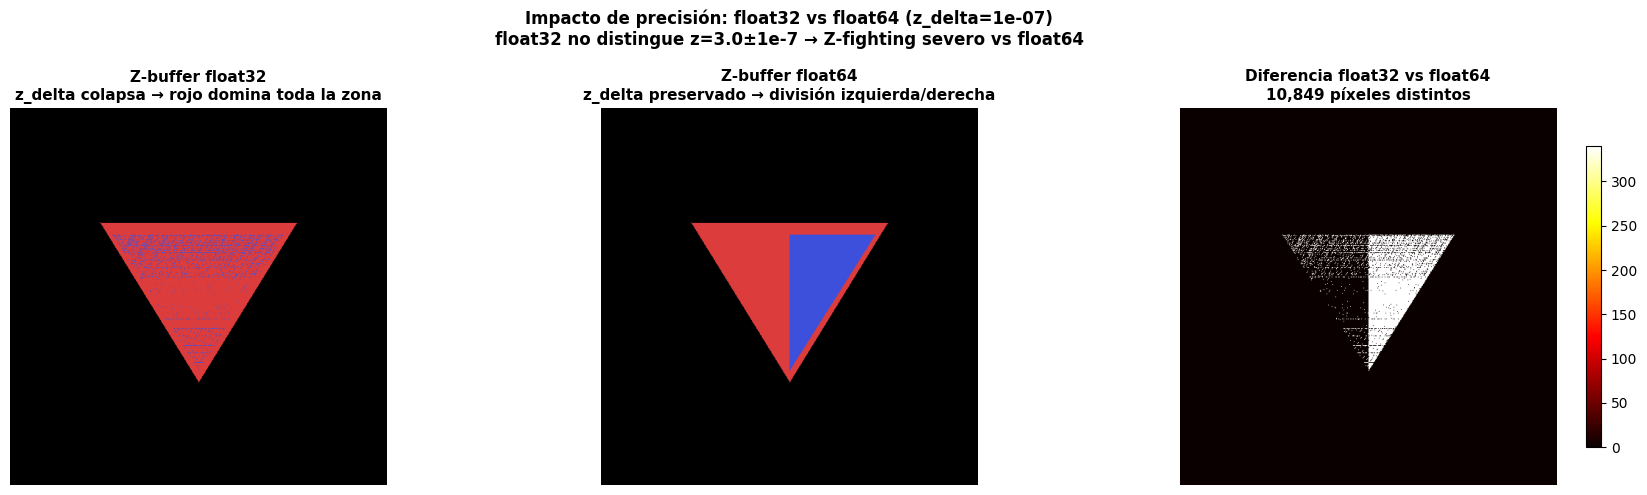

Diferencia de precisión: 10,849 píxeles distintos entre float32 y float64


In [9]:

# ─── Simular Z-fighting con precisión reducida (float32 vs float64) ───────────
def render_with_precision(triangles, dtype=np.float64, focal_length=500):
    """Renderiza con la precisión de punto flotante indicada."""
    color_buffer = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    depth_buffer = np.full((HEIGHT, WIDTH), np.inf, dtype=dtype)

    for verts3d, color, *_ in triangles:
        v0, v1, v2 = verts3d
        z0, z1, z2 = dtype(v0[2]), dtype(v1[2]), dtype(v2[2])
        p0 = project_point(v0, focal_length)
        p1 = project_point(v1, focal_length)
        p2 = project_point(v2, focal_length)

        min_x = max(0, min(p0[0], p1[0], p2[0]))
        max_x = min(WIDTH  - 1, max(p0[0], p1[0], p2[0]))
        min_y = max(0, min(p0[1], p1[1], p2[1]))
        max_y = min(HEIGHT - 1, max(p0[1], p1[1], p2[1]))

        area = edge_function(p0, p1, p2)
        if area == 0:
            continue

        for y in range(min_y, max_y + 1):
            for x in range(min_x, max_x + 1):
                p = (x, y)
                w0 = edge_function(p1, p2, p)
                w1 = edge_function(p2, p0, p)
                w2 = edge_function(p0, p1, p)
                if (w0 >= 0 and w1 >= 0 and w2 >= 0) or (w0 <= 0 and w1 <= 0 and w2 <= 0):
                    lam0, lam1, lam2 = dtype(w0/area), dtype(w1/area), dtype(w2/area)
                    z_interp = lam0*z0 + lam1*z1 + lam2*z2
                    if z_interp < depth_buffer[y, x]:
                        depth_buffer[y, x] = z_interp
                        color_buffer[y, x] = color

    return color_buffer, depth_buffer


# ─── float32 ULP en z=3.0 ≈ 2.38e-7  →  z_delta = 1e-7 colapsa a 0 en float32 ──
# float64 preserva z_delta = 1e-7  →  izquierda roja, derecha azul
# float32 colapsa z_delta → todos los z = 3.0 → el primero pintado (rojo) gana todo
z_base  = 3.0
z_delta = 1e-7

f32_ulp = float(np.float32(z_base + np.float32(2**-22))) - z_base
print(f"float32 ULP @ z={z_base}:  {f32_ulp:.2e}")
print(f"z_delta usado:              {z_delta:.0e}")
print(f"float32({z_base} - {z_delta}) = {np.float32(z_base - z_delta)}  "
      f"(¿igual a {z_base}? {np.float32(z_base - z_delta) == np.float32(z_base)})")
print(f"float32({z_base} + {z_delta}) = {np.float32(z_base + z_delta)}  "
      f"(¿igual a {z_base}? {np.float32(z_base + z_delta) == np.float32(z_base)})")
print()
print("→ float32 NO distingue z_delta=1e-7: AMBOS triángulos tienen z=3.0")
print("  El primero pintado (rojo) gana TODA la zona solapada.")
print("→ float64 SÍ distingue: produce la división correcta izq/der.")

# Planos cruzados: rojo (izq. cerca), azul (der. cerca)
crossing_scene = [
    # Rojo: izq. z=base-delta (más cerca), der. z=base+delta (más lejos)
    ([(-0.8, -0.6, z_base - z_delta), ( 0.8, -0.6, z_base + z_delta), (0.0,  0.7, z_base)],
     (220, 60, 60), "Rojo (izq. cercano)"),
    # Azul: izq. z=base+delta (más lejos), der. z=base-delta (más cerca)
    ([(-0.7, -0.5, z_base + z_delta), ( 0.7, -0.5, z_base - z_delta), (0.0,  0.6, z_base)],
     (60, 80, 220), "Azul (der. cercano)"),
]

img_f32, _ = render_with_precision(crossing_scene, dtype=np.float32)
img_f64, _ = render_with_precision(crossing_scene, dtype=np.float64)

diff_precision = np.abs(img_f32.astype(int) - img_f64.astype(int)).sum(axis=2)
px_diff = (diff_precision > 10).sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_f32)
axes[0].set_title("Z-buffer float32\nz_delta colapsa → rojo domina toda la zona",
                  fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_f64)
axes[1].set_title("Z-buffer float64\nz_delta preservado → división izquierda/derecha",
                  fontsize=11, fontweight='bold')
axes[1].axis('off')

im = axes[2].imshow(diff_precision, cmap='hot')
axes[2].set_title(f"Diferencia float32 vs float64\n{px_diff:,} píxeles distintos",
                  fontsize=11, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], shrink=0.8)

fig.suptitle(f"Impacto de precisión: float32 vs float64 (z_delta={z_delta:.0e})\n"
             "float32 no distingue z=3.0±1e-7 → Z-fighting severo vs float64",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('zfighting_float32_vs_float64.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Diferencia de precisión: {px_diff:,} píxeles distintos entre float32 y float64")


### 5.3 Resumen: problemas de precisión documentados

In [10]:
print(" DOCUMENTACIÓN DE PROBLEMAS DE PRECISIÓN DEL Z-BUFFER")
print("-" * 30)

problems = [
    (
        "Distribución no uniforme",
        "La precisión NDC NO es lineal. Se concentra cerca del near plane.\n"
        "  → Objetos lejanos tienen mucha menos resolución de profundidad."
    ),
    (
        "Efecto del rango near/far",
        "Un far/near ratio grande (ej: 1000/0.1 = 10000) provoca pérdida\n"
        "  grave de precisión en zonas lejanas. Regla: mantener ratio < 1000."
    ),
    (
        "Z-Fighting",
        "Dos superficies con z muy parecido 'compiten' por el mismo píxel.\n"
        "  El resultado depende del orden y la precisión del float.\n"
        "  Soluciones: polygon offset, mayor separación, usar float64."
    ),
    (
        "float32 vs float64",
        "float32 tiene ~7 dígitos decimales de precisión.\n"
        "  float64 tiene ~15 dígitos. Para z muy cercanos, float32 colapsa\n"
        "  ambos al mismo valor y el resultado es indeterminado."
    ),
]

for i, (title, desc) in enumerate(problems, 1):
    print(f"\n  {i}. {title}")
    for line in desc.split('\n'):
        print(f"     {line}")

print("\n" + "-" * 30)

 DOCUMENTACIÓN DE PROBLEMAS DE PRECISIÓN DEL Z-BUFFER
------------------------------

  1. Distribución no uniforme
     La precisión NDC NO es lineal. Se concentra cerca del near plane.
       → Objetos lejanos tienen mucha menos resolución de profundidad.

  2. Efecto del rango near/far
     Un far/near ratio grande (ej: 1000/0.1 = 10000) provoca pérdida
       grave de precisión en zonas lejanas. Regla: mantener ratio < 1000.

  3. Z-Fighting
     Dos superficies con z muy parecido 'compiten' por el mismo píxel.
       El resultado depende del orden y la precisión del float.
       Soluciones: polygon offset, mayor separación, usar float64.

  4. float32 vs float64
     float32 tiene ~7 dígitos decimales de precisión.
       float64 tiene ~15 dígitos. Para z muy cercanos, float32 colapsa
       ambos al mismo valor y el resultado es indeterminado.

------------------------------


---
## Conclusiones del Notebook 2

### Visualización del depth buffer
- El depth buffer se normaliza a $[0,1]$ dividiendo por el rango $[z_{min}, z_{max}]$
- Valores oscuros = más cercanos al observador
- El histograma muestra cómo se distribuyen los fragmentos en profundidad

### Precisión del Z-buffer
| Problema | Causa | Mitigación |
|---|---|---|
| **Distribución no uniforme** | Proyección perspectiva no lineal | Reverse-Z buffer |
| **Rango near/far amplio** | Pocos bits para lejanos | Reducir ratio far/near |
| **Z-fighting** | Superficies co-planares | Polygon offset, separar geometría |
| **float32 insuficiente** | Mantisa de 23 bits | Usar float64 o Reversed-Z |

---
*Taller de Visual Computing 2026 — Semana 3: Pipeline Gráfico / Z-Buffer*